## Stock Market Analysis — Next-Day Direction Prediction
End-to-end walkthrough: data, feature engineering, model evaluation, backtesting, and artifact export for the Streamlit app.

The two decisions that shape this notebook:

No shuffled cross-validation. Financial time series break the i.i.d. assumption behind k-fold CV — shuffling puts tomorrow in the training set and yesterday in the test set. Everything here uses expanding-window walk-forward validation.
Accuracy is not profit. A model can be right 55% of the time and lose money if it's wrong on the days that move most, or if trading costs eat the edge. Every model is scored as a trading signal against buy-and-hold, net of costs.

In [3]:
 %pip install matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 48.9 MB/s  0:00:00m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 81.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.8/4.8 MB 84.7 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [matplotlib]7 [matplotlib]

[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [14]:
%pip install scikit-learn joblib yfinance pyarrow plotly

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.2/8.2 MB 45.3 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.9/35.9 MB 75.1 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 81.5 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 73.1 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.4/20.4 MB 71.3 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14/14 [yfinance]/14 [plotly]learn]

[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [11]:
import zipfile, os
zipfile.ZipFile("stock-market-analysis.zip").extractall(".")
os.chdir("stock-market-analysis")
print(sorted(os.listdir()))

['.github', '.gitignore', 'README.md', 'app.ipynb', 'app.py', 'config', 'feature_metadata.joblib', 'pytest.ini', 'requirements.txt', 'scaler.joblib', 'src', 'stock_model.joblib', 'tests', 'train_model.py']


In [12]:
import os, sys

# walk up until we find the folder containing src/
d = os.getcwd()
while d != os.path.dirname(d):
    if os.path.isdir(os.path.join(d, "src")):
        sys.path.insert(0, d)
        os.chdir(d)
        break
    d = os.path.dirname(d)

print("root:", os.getcwd())
print("contents:", sorted(os.listdir()))

root: /Users/kavyadaggubati/stock-market-analysis
contents: ['.github', '.gitignore', 'README.md', 'app.ipynb', 'app.py', 'config', 'feature_metadata.joblib', 'pytest.ini', 'requirements.txt', 'scaler.joblib', 'src', 'stock_model.joblib', 'tests', 'train_model.py']


In [15]:
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
pd.set_option("display.width", 120)
plt.rcParams["figure.figsize"] = (12, 5)

from src.data.fetch import fetch_prices, synthetic_ohlcv
from src.features.build_features import build_features, feature_columns
from src.models.train import compare_models, walk_forward_evaluate, MODELS
from src.backtest.engine import backtest, score_returns

## 1. Load data

Set `TICKER` and run. `OFFLINE = True` uses a synthetic random walk instead — useful
for testing the pipeline without network access, and as a negative control later.

In [17]:
TICKER = "AAPL"
START = "2015-01-01"
OFFLINE = False

if OFFLINE:
    prices = synthetic_ohlcv()
    label = "SYNTHETIC"
else:
    prices = fetch_prices(TICKER, start=START, use_cache=False)
    label = TICKER

print(f"{label}: {len(prices)} rows, {prices.index.min().date()} to {prices.index.max().date()}")
prices.tail()
     

AAPL: 2917 rows, 2015-01-02 to 2026-08-10


Price,open,high,low,close,volume
date,,,,,
2026-08-04,302.469140,310.152516,301.060351,309.113403,68001000
2026-08-05,309.093424,311.441405,305.406631,310.732025,49438800
2026-08-06,314.069138,316.017470,308.963556,312.140808,46139900
2026-08-07,311.181643,314.538733,310.472233,313.059998,34437200
2026-08-10,306.829987,308.260010,304.609985,308.260010,44775100


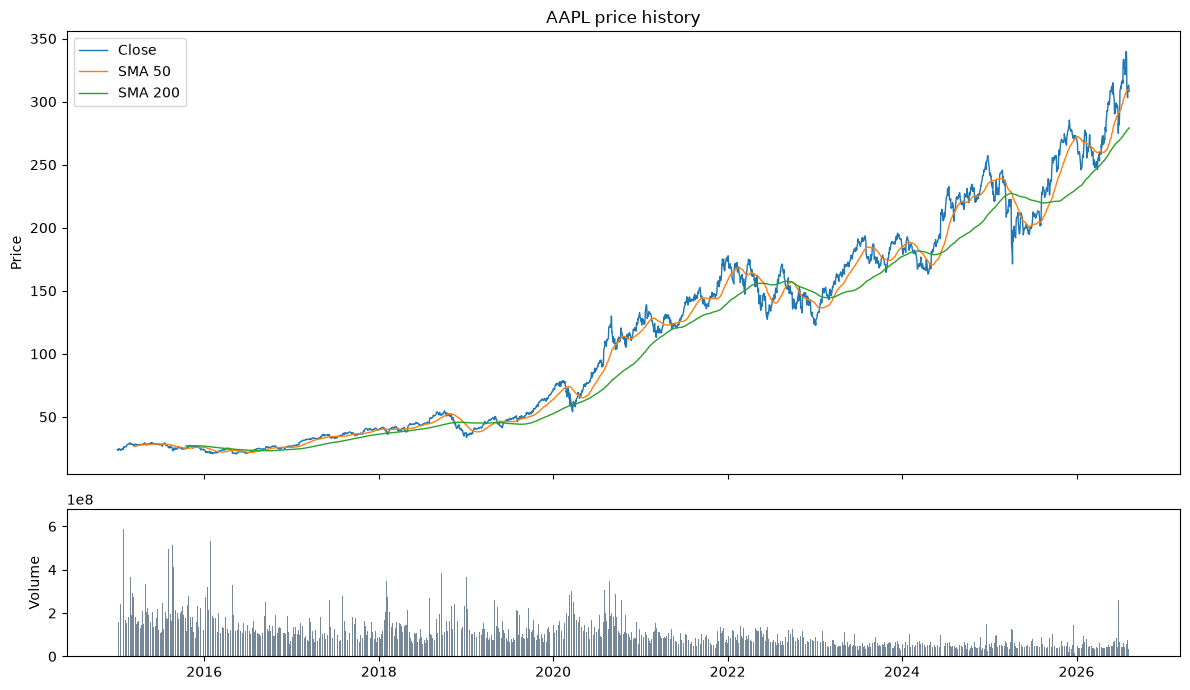

In [19]:
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, height_ratios=[3, 1], figsize=(12, 7))
ax1.plot(prices.index, prices["close"], lw=1, label="Close")
ax1.plot(prices.index, prices["close"].rolling(50).mean(), lw=1, label="SMA 50")
ax1.plot(prices.index, prices["close"].rolling(200).mean(), lw=1, label="SMA 200")
ax1.set_ylabel("Price"); ax1.legend(); ax1.set_title(f"{label} price history")
ax2.bar(prices.index, prices["volume"], width=1, color="lightslategray")
ax2.set_ylabel("Volume")
plt.tight_layout()

## 2. Return distribution

Worth looking at before modelling. Daily equity returns are roughly symmetric and fat-tailed — the direction split is close to 50/50, which is why the majority-class baseline is a genuinely hard benchmark.

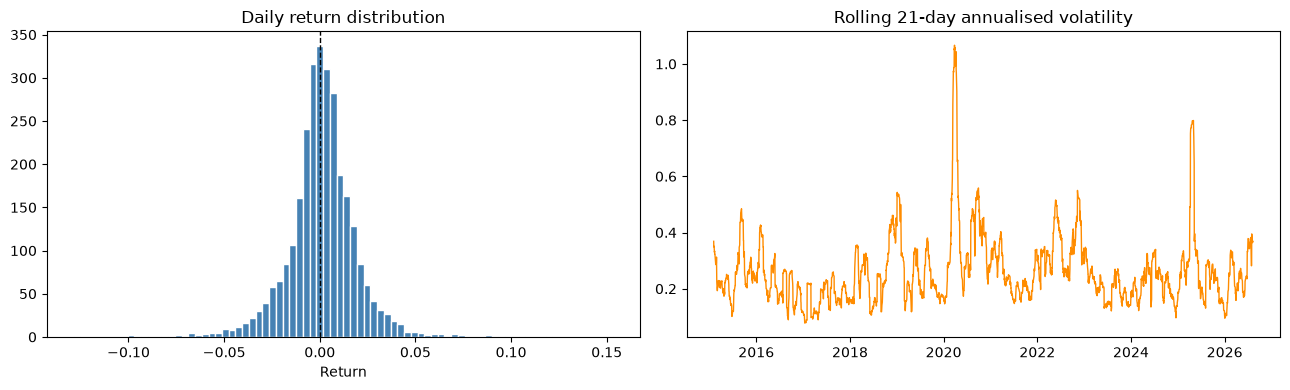

In [20]:
returns = prices["close"].pct_change().dropna()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
ax1.hist(returns, bins=80, color="steelblue", edgecolor="white")
ax1.axvline(0, color="black", lw=1, ls="--")
ax1.set_title("Daily return distribution"); ax1.set_xlabel("Return")
ax2.plot(returns.index, returns.rolling(21).std() * np.sqrt(252), lw=1, color="darkorange")
ax2.set_title("Rolling 21-day annualised volatility")
plt.tight_layout()

## 3. Feature engineering

24 features across six groups. Every one is computed from information available at or
before the close of day *t*; the target is the return realised on day *t+1*.

| Group | Features |
| --- | --- |
| Momentum | Lagged returns (1, 2, 3, 5, 10d), 5d and 21d cumulative |
| Trend | Close vs SMA (5, 10, 20, 50), EMA 12/26 ratio |
| Volatility | 10d and 21d realised vol, vol ratio, high–low range |
| Oscillators | RSI(14), MACD, MACD histogram, Bollinger position |
| Volume | Volume vs 20d SMA, volume change |
| Calendar | Day of week, month |

In [21]:
features = build_features(prices)
cols = feature_columns(features)

print(f"{len(features)} rows after warm-up, {len(cols)} features")
print(f"Target balance: {features['target_direction'].mean():.2%} up days")
features[cols].tail()

2867 rows after warm-up, 24 features
Target balance: 52.95% up days


,return_lag_1,return_lag_2,return_lag_3,return_lag_5,return_lag_10,return_5d,return_21d,close_over_sma_5,close_over_sma_10,close_over_sma_20,...,volatility_ratio,high_low_range,rsi_14,macd,macd_hist,bollinger_pos,volume_over_sma_20,volume_change,day_of_week,month
date,,,,,,,,,,,,,,,,,,,,,
2026-08-03,-0.017772,-0.073539,-0.014075,0.009409,0.003521,-0.099403,-0.016881,-0.065842,-0.071897,-0.063244,...,1.230900,0.030453,40.340780,0.014951,-0.009819,0.026779,0.371055,-0.433523,0,8
2026-08-04,0.019643,-0.017772,-0.073539,-0.005557,-0.005645,-0.090273,-0.010491,-0.029140,-0.048322,-0.044655,...,1.265929,0.029414,44.685135,0.010062,-0.011385,0.168569,0.213960,-0.093948,1,8
2026-08-05,0.005236,0.019643,-0.017772,-0.014075,-0.012980,-0.080399,0.001094,-0.007113,-0.038937,-0.039298,...,1.274964,0.019421,45.839624,0.006726,-0.011688,0.211944,-0.123762,-0.272970,2,8
2026-08-06,0.004534,0.005236,0.019643,-0.073539,0.035317,-0.063042,-0.003127,0.010957,-0.031812,-0.034374,...,1.275856,0.022599,46.878824,0.004417,-0.011130,0.251955,-0.180789,-0.066727,3,8
2026-08-07,0.002945,0.004534,0.005236,-0.017772,0.011681,0.014308,-0.009139,0.011042,-0.022999,-0.031232,...,1.149974,0.012990,47.585490,0.002809,-0.010155,0.276394,-0.388735,-0.253635,4,8


## Leakage check
The single most important cell in this notebook. If any feature used forward-looking information, its value on a given date would change once later rows were removed. Truncating the history and recomputing must produce identical values on the overlap.

In [22]:
truncated = build_features(prices.iloc[:-100])
shared = truncated.index.intersection(features.index)

identical = np.allclose(
    features.loc[shared, cols].to_numpy(),
    truncated.loc[shared, cols].to_numpy(),
    rtol=1e-9,
)
print(f"Overlapping rows checked: {len(shared)}")
print(f"No lookahead leakage: {identical}")
assert identical, "FEATURE LEAKAGE DETECTED — do not trust anything below this cell"

corr = features[cols].corrwith(features["target_return"]).sort_values(key=abs, ascending=False)
print("\nTop feature correlations with next-day return:")
print(corr.head(8).to_string())
     

Overlapping rows checked: 2767
No lookahead leakage: True

Top feature correlations with next-day return:
return_lag_1        -0.052465
close_over_sma_5    -0.047841
close_over_sma_10   -0.041004
return_5d           -0.036186
return_lag_10       -0.029650
return_lag_3        -0.029360
close_over_sma_20   -0.024778
day_of_week         -0.022321


Those correlations are tiny — typically under 0.05. That is the honest starting point for this problem, and it sets expectations for what follows.

## 4. Walk-forward model evaluation
TimeSeriesSplit builds expanding windows: fold 1 trains on the earliest slice and tests on what follows, fold 2 trains on everything through fold 1's test set, and so on. No model ever sees data from its own test period.

In [23]:
leaderboard = compare_models(features, n_splits=5)
leaderboard

,model,mean_accuracy,std_accuracy,mean_f1,mean_roc_auc
0,baseline_majority,0.525367,0.030398,0.559721,0.500000
1,logistic_regression,0.520755,0.023629,0.595761,0.501569
2,random_forest,0.505660,0.020343,0.590992,0.498354
3,gradient_boosting,0.488889,0.029152,0.521059,0.484537


Majority-class baseline: 0.5254
Best model (baseline_majority): 0.5254
Edge over baseline: +0.0000


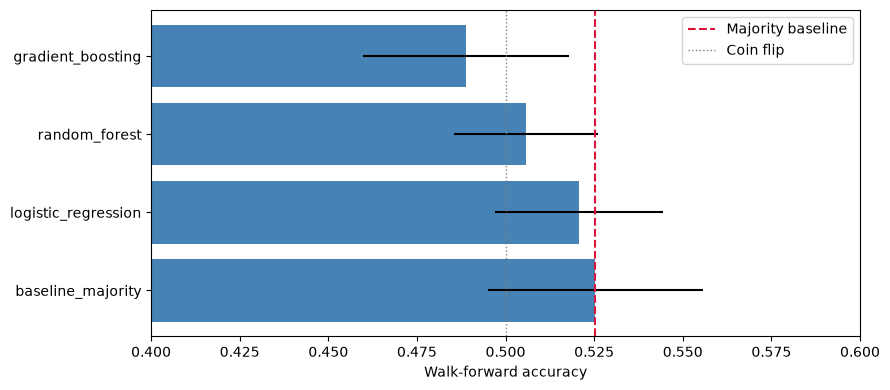

In [24]:
baseline = leaderboard.loc[leaderboard["model"] == "baseline_majority", "mean_accuracy"].iloc[0]
best = leaderboard.iloc[0]

print(f"Majority-class baseline: {baseline:.4f}")
print(f"Best model ({best['model']}): {best['mean_accuracy']:.4f}")
print(f"Edge over baseline: {best['mean_accuracy'] - baseline:+.4f}")

fig, ax = plt.subplots(figsize=(9, 4))
ax.barh(leaderboard["model"], leaderboard["mean_accuracy"],
        xerr=leaderboard["std_accuracy"], color="steelblue")
ax.axvline(baseline, color="crimson", ls="--", lw=1.5, label="Majority baseline")
ax.axvline(0.5, color="grey", ls=":", lw=1, label="Coin flip")
ax.set_xlim(0.4, 0.6); ax.set_xlabel("Walk-forward accuracy"); ax.legend()
plt.tight_layout()

In [25]:
result = walk_forward_evaluate(features, model_name="gradient_boosting", n_splits=5)

fold_df = pd.DataFrame([{
    "fold": f.fold, "train_size": f.train_size, "test_size": f.test_size,
    "accuracy": f.accuracy, "f1": f.f1, "roc_auc": f.roc_auc,
} for f in result.folds])
print("Fold-by-fold — note the expanding training window:")
fold_df

Fold-by-fold — note the expanding training window:


,fold,train_size,test_size,accuracy,f1,roc_auc
0,1,482,477,0.440252,0.415755,0.460230
1,2,959,477,0.473795,0.469345,0.492573
2,3,1436,477,0.524109,0.565966,0.511592
3,4,1913,477,0.505241,0.564576,0.493943
4,5,2390,477,0.501048,0.589655,0.464349


Fold-to-fold variance is usually larger than the gap between models. That is a signal in itself: it means apparent differences between models on this data are mostly noise, and picking a winner on mean accuracy alone would be overfitting the evaluation.

## 5. Backtest
Converts the walk-forward predictions into a position (long when the model predicts up, flat otherwise), charges transaction costs on every position change, and compares the result against buy-and-hold over the same window.

In [26]:
bt = backtest(features, model_name="gradient_boosting", n_splits=5, cost_bps=5.0)
strategy, benchmark = bt["strategy"], bt["buy_and_hold"]

pd.DataFrame({"strategy": strategy.summary(), "buy_and_hold": benchmark.summary()})

,strategy,buy_and_hold
total_return,1.338893,9.106642
annualised_return,0.093931,0.276871
annualised_volatility,0.222660,0.296025
sharpe_ratio,0.421856,0.935299
max_drawdown,-0.414161,-0.385159
hit_rate,0.280084,0.535849
n_trades,2385.000000,2385.000000


Time in market: 54.4%
Excess return vs buy-and-hold: -776.77%


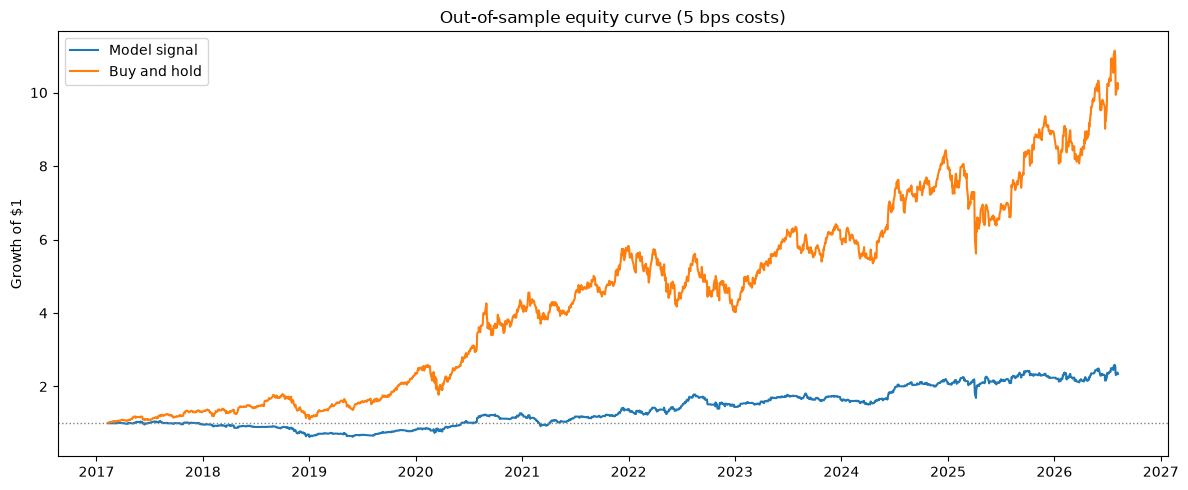

In [27]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(strategy.equity_curve.index, strategy.equity_curve, lw=1.5, label="Model signal")
ax.plot(benchmark.equity_curve.index, benchmark.equity_curve, lw=1.5, label="Buy and hold")
ax.axhline(1.0, color="grey", ls=":", lw=1)
ax.set_ylabel("Growth of $1"); ax.set_title("Out-of-sample equity curve (5 bps costs)")
ax.legend(); plt.tight_layout()

print(f"Time in market: {bt['days_in_market']:.1%}")
print(f"Excess return vs buy-and-hold: {bt['excess_return']:+.2%}")

## Cost sensitivity
How fast does the edge disappear as trading gets more expensive? If the strategy only works at zero cost, it doesn't work.

,cost_bps,total_return,sharpe,excess_vs_hold
0,0,2.702150,0.666009,-6.404491
1,2,2.080978,0.566969,-7.025664
2,5,1.338893,0.421856,-7.767749
3,10,0.477294,0.189017,-8.629348
4,20,-0.411047,-0.244017,-9.517689
5,50,-0.962888,-1.304549,-10.069529


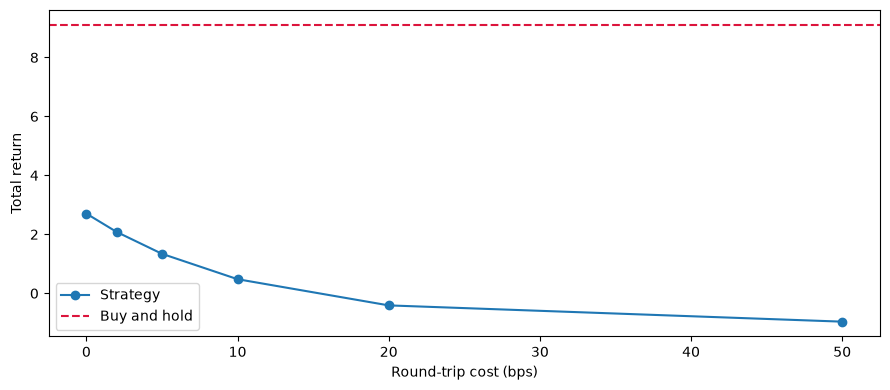

In [29]:
rows = []
for cost in [0, 2, 5, 10, 20, 50]:
    r = backtest(features, model_name="gradient_boosting", n_splits=5, cost_bps=cost)
    rows.append({
        "cost_bps": cost,
        "total_return": r["strategy"].total_return,
        "sharpe": r["strategy"].sharpe_ratio,
        "excess_vs_hold": r["excess_return"],
    })

sensitivity = pd.DataFrame(rows)
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(sensitivity["cost_bps"], sensitivity["total_return"], marker="o", label="Strategy")
ax.axhline(benchmark.total_return, color="crimson", ls="--", label="Buy and hold")
ax.set_xlabel("Round-trip cost (bps)"); ax.set_ylabel("Total return"); ax.legend()
plt.tight_layout()
sensitivity

## 6. Negative control
Re-run the whole pipeline on a synthetic random walk. There is no signal to find, so every model should land at the baseline. If a model appears to beat it here, the pipeline is leaking — this is the check that makes the results above trustworthy.

In [32]:
control = build_features(synthetic_ohlcv(n_days=1500, seed=99))
control_board = compare_models(control, n_splits=5)

control_baseline = control_board.loc[
    control_board["model"] == "baseline_majority", "mean_accuracy"].iloc[0]
control_best = control_board["mean_accuracy"].max()

print(control_board.to_string(index=False))
print(f"\nBaseline: {control_baseline:.4f}  |  Best: {control_best:.4f}")
print(f"Gap: {control_best - control_baseline:+.4f}  (should be near zero)")

              model  mean_accuracy  std_accuracy  mean_f1  mean_roc_auc
logistic_regression       0.515353      0.016049 0.554248      0.508554
  baseline_majority       0.512863      0.016092 0.677852      0.500000
      random_forest       0.508714      0.017526 0.580665      0.510898
  gradient_boosting       0.499585      0.029176 0.530740      0.508406

Baseline: 0.5129  |  Best: 0.5154
Gap: +0.0025  (should be near zero)


## 7. Export artifacts
Refit on the full history and persist the model, scaler, and feature metadata for the Streamlit app. The metadata file is the contract between training and serving: if the app builds features in a different order than the model was trained on, predictions are silently wrong, so the order is stored and verified at load time.

In [34]:
%pip install --upgrade --force-reinstall pyarrow

  Using cached pyarrow-25.0.1-cp314-cp314-macosx_12_0_arm64.whl.metadata (3.0 kB)
Using cached pyarrow-25.0.1-cp314-cp314-macosx_12_0_arm64.whl (35.9 MB)
  Attempting uninstall: pyarrow
    Found existing installation: pyarrow 25.0.1
    Uninstalling pyarrow-25.0.1:
      Successfully uninstalled pyarrow-25.0.1

[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [43]:
import train_model
from src.data.fetch import fetch_prices as _fetch

train_model.fetch_prices = (
    lambda ticker, start="2015-01-01", end=None, use_cache=True:
    _fetch(ticker, start=start, end=end, use_cache=False)
)
print("cache disabled")

cache disabled


In [44]:
from train_model import train

metadata = train(ticker=TICKER, start=START, model_name="gradient_boosting",
                 n_splits=5, offline=OFFLINE)

print("\nArtifacts written:")
print("  stock_model.joblib       fitted classifier")
print("  scaler.joblib            fitted StandardScaler")
print("  feature_metadata.joblib  feature order + training metrics")
print("\nLaunch the app with:  streamlit run app.py")

Fetching AAPL from 2015-01-01...
2867 rows, 24 features

Walk-forward evaluation...
  accuracy 0.4889 (+/- 0.0292)
  roc auc  0.4845

Backtest (5 bps costs)...
  strategy sharpe    +0.422
  buy-and-hold sharpe +0.935
  excess return       -776.77%

Saved stock_model.joblib, scaler.joblib, feature_metadata.joblib

Artifacts written:
  stock_model.joblib       fitted classifier
  scaler.joblib            fitted StandardScaler
  feature_metadata.joblib  feature order + training metrics

Launch the app with:  streamlit run app.py


## Conclusions
What the pipeline does. Ingests OHLCV data with a Parquet cache layer, engineers 24 lag-safe time-series features, evaluates four models under expanding-window walk-forward validation, and scores the resulting signal as a cost-aware trading strategy against buy-and-hold.

What the results show. Accuracy sits marginally above the majority-class baseline, and the edge usually does not survive realistic transaction costs. This is the expected outcome — daily direction prediction from price history alone sits close to the efficient-market limit.

Why that's reported rather than tuned away. It would be easy to produce an impressive number here: shuffle the cross-validation folds, drop transaction costs, or tune hyperparameters against the test set. All three are common in published stock-prediction projects and all three are wrong. The value of this project is the evaluation discipline — the leakage guard, the baseline comparison, the negative control, and the cost sensitivity analysis — not a profitable strategy.

Where a real edge would come from. Not from more model complexity on the same inputs. Alternative data — order-flow imbalance, options positioning, earnings-call sentiment, cross-asset signals — is where the information actually lives.

Not financial advice. Educational project only.